# Predict House Prices


* Inputs are numerical
* Output is continuous

Use the built-in California Housing dataset from scikit-learn.



###  Key concepts

* Regression vs Classification
* Decision Trees vs Random Forest
* Ensemble learning
* Training a regressor
* Evaluating with RMSE and R²
* Feature importance



# Step 1: Import Libraries


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


# Step 2: Load Dataset


In [2]:

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(X.head())
print(y[:5])


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
[4.526 3.585 3.521 3.413 3.422]


# Understand Features


| Feature            | Meaning         |
| ------------------ | --------------- |
| MedInc             | Median income   |
| HouseAge           | Age of house    |
| AveRooms           | Average rooms   |
| Population         | Area population |
| Latitude/Longitude | Location        |

Target:

* Median house price


# Step 3: Train-Test Split


In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Step 4: Create Random Forest Regressor

In [4]:

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)




## Explanation:

* `n_estimators=100`
  → 100 decision trees

Random Forest:

* Builds many trees
* Combines predictions
* Reduces overfitting


# Step 6: Train the Model (Took 30 seconds on CPU)

In [5]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Step 7: Make Predictions


In [7]:

y_pred = model.predict(X_test)



# Random Forest Intuition

```text
Tree 1 predicts → 2.1
Tree 2 predicts → 2.5
Tree 3 predicts → 2.3
...
Final Prediction = Average
```

This reduces:

* Variance
* Overfitting
* Noise sensitivity


In [19]:
print(X_test.loc[3])
print("----------------")
print("actual price :", y_test[3])
print("predict price:", y_pred[3])

MedInc          5.643100
HouseAge       52.000000
AveRooms        5.817352
AveBedrms       1.073059
Population    558.000000
AveOccup        2.547945
Latitude       37.850000
Longitude    -122.250000
Name: 3, dtype: float64
----------------
actual price : 2.186
predict price: 2.5296099999999995


# Step 8: Evaluate the Model

In [8]:

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE : 0.32754256845930246
RMSE: 0.5053399773665033
R² Score: 0.8051230593157366


# Metrics

## MAE

Average prediction error.

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

---

## RMSE

Penalizes large errors more strongly.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$$

---

## R² Score

Measures goodness of fit.

$$R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}$$


# Step 9: Actual vs Predicted Plot

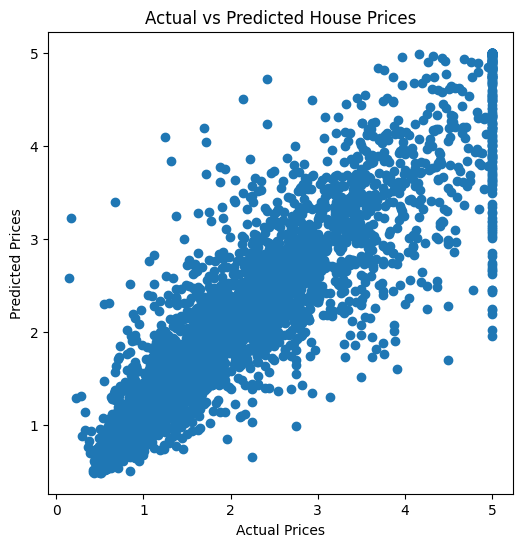

In [9]:

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()


* Points near diagonal → good predictions



# Step 10: Feature Importance


MedInc        0.524871
AveOccup      0.138443
Latitude      0.088936
Longitude     0.088629
HouseAge      0.054593
AveRooms      0.044272
Population    0.030650
AveBedrms     0.029606
dtype: float64


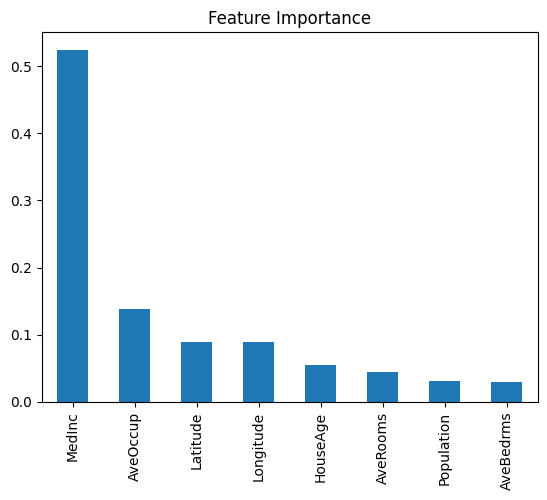

In [10]:

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()




### Observation:

* Median income is most important


---

# Important Hyperparameters

| Parameter         | Meaning                  |
| ----------------- | ------------------------ |
| n_estimators      | Number of trees          |
| max_depth         | Depth of trees           |
| min_samples_split | Minimum samples to split |

---


In [21]:
# Small Experiment: Took 30 seconds

for n in [10, 50, 100]:
    
    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    score = model.score(X_test, y_test)
    
    print(f"{n} Trees -> R-square Score: {score:.4f}")


10 Trees -> R-square Score: 0.7831
50 Trees -> R-square Score: 0.8037
100 Trees -> R-square Score: 0.8051
